In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 41.4 MB/s eta 0:00:00


In [2]:
# ============================================
# PART 1: IMPORT LIBRARIES
# ============================================

!pip install rdkit

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
import re
import joblib

# Machine Learning Libraries
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

import xgboost as xgb
import lightgbm as lgb

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# ============================================
# PART 2: UPLOAD & LOAD QSAR DATASET
# ============================================

print("="*50)
print("📤 STEP 1: Upload QSAR Dataset")
print("="*50)
print("\nUpload your QSAR dataset file:")
print("  📁 qsar_cox2_ic50.csv")

uploaded_qsar = files.upload()
qsar_filename = list(uploaded_qsar.keys())[0]
print(f"\n✅ File uploaded: {qsar_filename}")

qsar_data = pd.read_csv(qsar_filename, sep=';', encoding='latin-1')
print(f"✅ QSAR Dataset loaded: {qsar_data.shape}")


📤 STEP 1: Upload QSAR Dataset

Upload your QSAR dataset file:
  📁 qsar_cox2_ic50.csv


Saving qsar_cox2_ic50.csv to qsar_cox2_ic50.csv

✅ File uploaded: qsar_cox2_ic50.csv
✅ QSAR Dataset loaded: (15314, 48)


In [4]:
# ============================================
# PART 3: INITIAL EXPLORATION
# ============================================

print("\n" + "="*50)
print("📊 STEP 2: Initial Exploration")
print("="*50)

print(f"\n📊 QSAR Dataset (COX-2)")
print("-" * 40)
print(f"Shape: {qsar_data.shape}")
print(f"Columns ({len(qsar_data.columns)}):")
print(qsar_data.columns.tolist()[:10], "...")
print(f"\nFirst 3 rows:")
display(qsar_data.head(3))

# Check target
print("\n" + "="*50)
print("🎯 STEP 3: Target Columns Check")
print("="*50)

print("\n🔬 QSAR Target (pIC50):")
if 'pChEMBL Value' in qsar_data.columns:
    print(f"  ✅ Found: 'pChEMBL Value'")
    print(f"  Values: {qsar_data['pChEMBL Value'].min():.2f} to {qsar_data['pChEMBL Value'].max():.2f}")
    print(f"  Missing: {qsar_data['pChEMBL Value'].isnull().sum()}")
else:
    print("  ❌ 'pChEMBL Value' not found")

print("\n🧬 SMILES Column:")
if 'Smiles' in qsar_data.columns:
    print(f"  ✅ Found: 'Smiles'")
else:
    print("  ❌ No 'Smiles' column found")


📊 STEP 2: Initial Exploration

📊 QSAR Dataset (COX-2)
----------------------------------------
Shape: (15314, 48)
Columns (48):
['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Relation'] ...

First 3 rows:


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL144840,NaN,NaN,196.27,0.0,2.72,37,CCC(=O)Oc1ccccc1SC,IC50,'>',...,CHEMBL1131194,1,Scientific Literature,J Med Chem,1998.0,NaN,NaN,NaN,NaN,1000.00
1,CHEMBL18264,NaN,NaN,350.34,0.0,2.84,MF-tricyclic,CS(=O)(=O)c1ccc(C2=C(c3ccc(F)c(F)c3)C(=O)OC2)cc1,IC50,'=',...,CHEMBL1147594,1,Scientific Literature,Bioorg Med Chem Lett,2004.0,NaN,NaN,NaN,NaN,0.48
2,CHEMBL289484,NaN,NaN,404.88,0.0,3.77,92,CCOC(=O)c1cn(-c2ccc(S(C)(=O)=O)cc2)c(-c2ccc(Cl...,IC50,'=',...,CHEMBL1134614,1,Scientific Literature,J Med Chem,2001.0,NaN,NaN,NaN,NaN,5.24



🎯 STEP 3: Target Columns Check

🔬 QSAR Target (pIC50):
  ✅ Found: 'pChEMBL Value'
  Values: 4.00 to 10.70
  Missing: 9025

🧬 SMILES Column:
  ✅ Found: 'Smiles'


In [5]:
# ============================================
# PART 4: DATA QUALITY CHECK
# ============================================

print("\n" + "="*50)
print("🔍 STEP 4: Data Quality Check")
print("="*50)

print(f"\n📊 Missing Values: {qsar_data.isnull().sum().sum()} total missing")

qsar_dups = qsar_data.duplicated().sum() if 'Smiles' in qsar_data.columns else 0
print(f"🔁 Duplicates: {qsar_dups} duplicate rows")

def validate_smiles(smiles_list, n=500):
    valid = 0
    total = 0
    for s in smiles_list[:n]:
        if pd.notna(s) and isinstance(s, str):
            total += 1
            try:
                mol = Chem.MolFromSmiles(s)
                if mol:
                    valid += 1
            except:
                pass
    return valid, total

if 'Smiles' in qsar_data.columns:
    valid, total = validate_smiles(qsar_data['Smiles'], 500)
    print(f"🧪 Valid SMILES (first 500): {valid}/{total} valid ({valid/total*100:.1f}%)")


🔍 STEP 4: Data Quality Check

📊 Missing Values: 274591 total missing
🔁 Duplicates: 14 duplicate rows
🧪 Valid SMILES (first 500): 496/496 valid (100.0%)



📈 STEP 6: Target Distribution


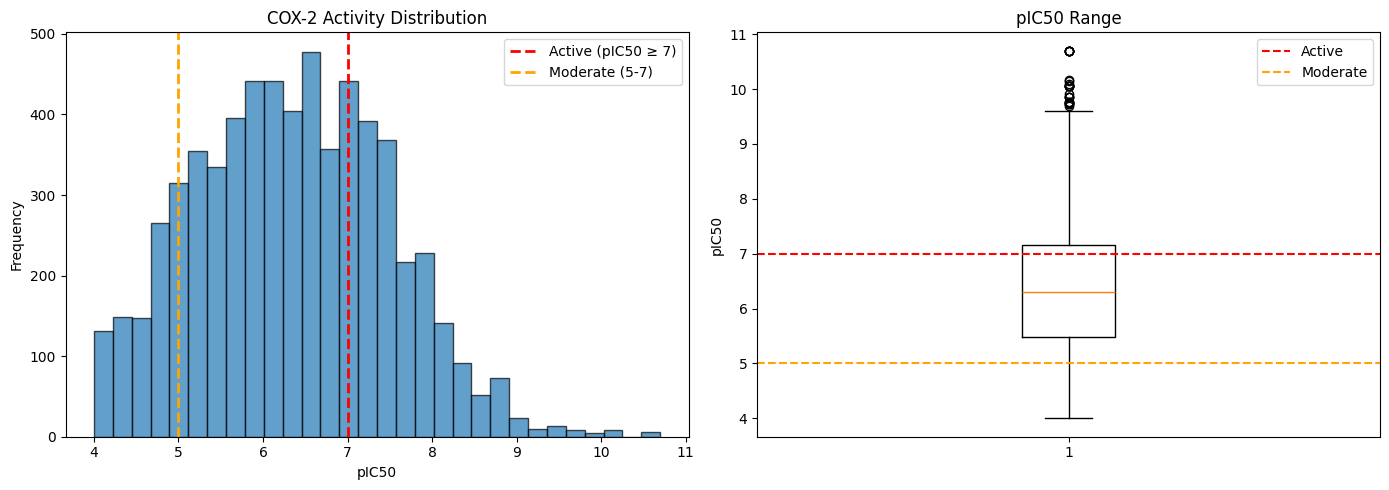

In [6]:
# ============================================
# PART 6: TARGET DISTRIBUTION VISUALIZATION
# ============================================

print("\n" + "="*50)
print("📈 STEP 6: Target Distribution")
print("="*50)

# QSAR pIC50 Distribution
if 'pChEMBL Value' in qsar_data.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    axes[0].hist(qsar_data['pChEMBL Value'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=7, color='red', linestyle='--', linewidth=2, label='Active (pIC50 ≥ 7)')
    axes[0].axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Moderate (5-7)')
    axes[0].set_xlabel('pIC50')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('COX-2 Activity Distribution')
    axes[0].legend()

    # Box plot
    axes[1].boxplot(qsar_data['pChEMBL Value'].dropna())
    axes[1].set_ylabel('pIC50')
    axes[1].set_title('pIC50 Range')
    axes[1].axhline(y=7, color='red', linestyle='--', label='Active')
    axes[1].axhline(y=5, color='orange', linestyle='--', label='Moderate')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [7]:
# ============================================
# Data Preprocessing
# ============================================

In [8]:
# ============================================
# PART 5: QSAR DATA CLEANING
# ============================================

print("\n" + "="*60)
print("🔬 STEP 5: QSAR Data Cleaning")
print("="*60)

# 5.1 Keep only IC50 data
print("\n📌 5.1 Filtering IC50 data...")
qsar_ic50 = qsar_data[qsar_data['Standard Type'] == 'IC50'].copy()
print(f"   Before: {len(qsar_data)} rows")
print(f"   After IC50 filter: {len(qsar_ic50)} rows")

# 5.2 Keep only Homo sapiens
print("\n📌 5.2 Filtering Human data...")
qsar_human = qsar_ic50[qsar_ic50['Target Organism'] == 'Homo sapiens'].copy()
print(f"   After Human filter: {len(qsar_human)} rows")

# 5.3 Keep only valid pIC50 values
print("\n📌 5.3 Filtering valid pIC50...")
qsar_valid = qsar_human[qsar_human['pChEMBL Value'].notna()].copy()
print(f"   After pIC50 filter: {len(qsar_valid)} rows")

# 5.4 Remove duplicate SMILES (keep highest pIC50)
print("\n📌 5.4 Removing duplicate SMILES...")
qsar_clean = qsar_valid.sort_values('pChEMBL Value', ascending=False)
qsar_clean = qsar_clean.drop_duplicates(subset=['Smiles'], keep='first')
print(f"   After removing duplicates: {len(qsar_clean)} rows")

# 5.5 Remove invalid SMILES using RDKit
print("\n📌 5.5 Validating SMILES...")
def is_valid_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

qsar_clean['valid_smiles'] = qsar_clean['Smiles'].apply(is_valid_smiles)
qsar_clean = qsar_clean[qsar_clean['valid_smiles']].drop('valid_smiles', axis=1)
print(f"   After SMILES validation: {len(qsar_clean)} rows")

# 5.6 Keep only essential columns
print("\n📌 5.6 Selecting essential columns...")
qsar_columns = ['Smiles', 'pChEMBL Value', 'Standard Value', 'Molecule ChEMBL ID']
qsar_clean = qsar_clean[qsar_columns]
print(f"   Final QSAR dataset: {qsar_clean.shape}")
print(f"   Columns: {qsar_clean.columns.tolist()}")

# 5.7 Rename columns for consistency
qsar_clean = qsar_clean.rename(columns={
    'pChEMBL Value': 'pIC50',
    'Standard Value': 'IC50_nM',
    'Molecule ChEMBL ID': 'Molecule_ID'
})

# 5.8 Add Activity Class
print("\n📌 5.7 Creating activity classes...")
def get_activity_class(pic50):
    if pic50 >= 7.0:
        return 'Active'
    elif pic50 >= 5.0:
        return 'Moderate'
    else:
        return 'Inactive'

qsar_clean['Activity_Class'] = qsar_clean['pIC50'].apply(get_activity_class)
qsar_clean['is_active'] = (qsar_clean['pIC50'] >= 7.0).astype(int)

print(f"\n📊 Activity Class Distribution:")
print(qsar_clean['Activity_Class'].value_counts())

# 5.9 Save cleaned QSAR data
qsar_clean.to_csv('qsar_cleaned.csv', index=False)
print("\n✅ QSAR cleaned data saved as 'qsar_cleaned.csv'")


🔬 STEP 5: QSAR Data Cleaning

📌 5.1 Filtering IC50 data...
   Before: 15314 rows
   After IC50 filter: 8504 rows

📌 5.2 Filtering Human data...
   After Human filter: 8504 rows

📌 5.3 Filtering valid pIC50...
   After pIC50 filter: 6116 rows

📌 5.4 Removing duplicate SMILES...
   After removing duplicates: 4393 rows

📌 5.5 Validating SMILES...
   After SMILES validation: 4392 rows

📌 5.6 Selecting essential columns...
   Final QSAR dataset: (4392, 4)
   Columns: ['Smiles', 'pChEMBL Value', 'Standard Value', 'Molecule ChEMBL ID']

📌 5.7 Creating activity classes...

📊 Activity Class Distribution:
Activity_Class
Moderate    2492
Active      1264
Inactive     636
Name: count, dtype: int64

✅ QSAR cleaned data saved as 'qsar_cleaned.csv'


In [9]:
# ============================================
# PART 6: FEATURE ENGINEERING (RDKit Descriptors)
# ============================================

print("\n" + "="*60)
print("🧬 STEP 6: Feature Engineering")
print("="*60)

def calculate_rdkit_descriptors(smiles_list):
    """Calculate molecular descriptors for each SMILES"""
    descriptors = []
    desc_names = []

    selected_descriptors = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors',
                           'TPSA', 'NumRotatableBonds', 'FractionCsp3',
                           'RingCount', 'HeavyAtomCount', 'NumAromaticRings']

    for i, smiles in enumerate(smiles_list):
        if i % 500 == 0:
            print(f"   Processing molecule {i}/{len(smiles_list)}...")
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                row = []
                for desc_name in selected_descriptors:
                    try:
                        func = getattr(Descriptors, desc_name)
                        value = func(mol)
                        row.append(value)
                    except:
                        row.append(np.nan)
                descriptors.append(row)
                if i == 0:
                    desc_names = selected_descriptors
            else:
                descriptors.append([np.nan] * len(selected_descriptors))
        except:
            descriptors.append([np.nan] * len(selected_descriptors))

    return pd.DataFrame(descriptors, columns=desc_names)

print("\n📌 6.1 Calculating RDKit descriptors...")
qsar_smiles = qsar_clean['Smiles'].tolist()
qsar_descriptors = calculate_rdkit_descriptors(qsar_smiles)

# Remove columns with ALL NaN values
print("\n📌 6.2 Removing all-NaN columns...")
before = qsar_descriptors.shape
qsar_descriptors = qsar_descriptors.dropna(axis=1, how='all')
print(f"   Before: {before}, After: {qsar_descriptors.shape}")

# Combine with existing data
qsar_features = pd.concat([qsar_clean.reset_index(drop=True),
                           qsar_descriptors.reset_index(drop=True)], axis=1)

# Handle missing values ONLY in numeric columns
print("\n📌 6.3 Handling missing values...")
numeric_cols = qsar_features.select_dtypes(include=[np.number]).columns.tolist()
print(f"   Numeric columns: {len(numeric_cols)}")

qsar_features[numeric_cols] = qsar_features[numeric_cols].fillna(qsar_features[numeric_cols].median())

non_numeric_cols = qsar_features.select_dtypes(exclude=[np.number]).columns.tolist()
for col in non_numeric_cols:
    if qsar_features[col].isnull().any():
        mode_val = qsar_features[col].mode()[0] if not qsar_features[col].mode().empty else 'Unknown'
        qsar_features[col] = qsar_features[col].fillna(mode_val)
        print(f"   Filled non-numeric column '{col}' with '{mode_val}'")

print(f"\n   QSAR features shape: {qsar_features.shape}")
print(f"   Feature columns (numeric): {numeric_cols[:10]}...")

# 6.4 Save feature-engineered data
qsar_features.to_csv('qsar_with_features.csv', index=False)
print("\n✅ QSAR with features saved as 'qsar_with_features.csv'")


🧬 STEP 6: Feature Engineering

📌 6.1 Calculating RDKit descriptors...
   Processing molecule 0/4392...
   Processing molecule 500/4392...
   Processing molecule 1000/4392...
   Processing molecule 1500/4392...
   Processing molecule 2000/4392...
   Processing molecule 2500/4392...
   Processing molecule 3000/4392...
   Processing molecule 3500/4392...
   Processing molecule 4000/4392...

📌 6.2 Removing all-NaN columns...
   Before: (4392, 10), After: (4392, 8)

📌 6.3 Handling missing values...
   Numeric columns: 11

   QSAR features shape: (4392, 14)
   Feature columns (numeric): ['pIC50', 'IC50_nM', 'is_active', 'MolWt', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'NumRotatableBonds', 'RingCount', 'HeavyAtomCount']...

✅ QSAR with features saved as 'qsar_with_features.csv'


In [10]:
# ============================================
# PART 7: PREPARE DATA FOR MODELING
# ============================================

print("\n" + "="*60)
print("📊 STEP 7: Prepare Data for Modeling")
print("="*60)

# 7.1 Prepare QSAR features
print("\n📌 7.1 Preparing QSAR features...")
feature_cols = qsar_descriptors.columns.tolist()
X_qsar = qsar_features[feature_cols].copy()
y_qsar = qsar_features['pIC50'].copy()
y_qsar_class = qsar_features['is_active'].copy()

print(f"   QSAR features: {X_qsar.shape}")
print(f"   QSAR target (pIC50): {y_qsar.shape}")
print(f"   QSAR target (binary): {y_qsar_class.shape}")

# 7.2 Scale features
print("\n📌 7.2 Scaling features...")
scaler_qsar = StandardScaler()
X_qsar_scaled = scaler_qsar.fit_transform(X_qsar)
print(f"   QSAR features scaled: {X_qsar_scaled.shape}")

# 7.3 Train-test split
print("\n📌 7.3 Splitting data for training...")

X_qsar_train, X_qsar_test, y_qsar_train, y_qsar_test = train_test_split(
    X_qsar_scaled, y_qsar, test_size=0.2, random_state=42
)

X_qsar_train_cls, X_qsar_test_cls, y_qsar_train_cls, y_qsar_test_cls = train_test_split(
    X_qsar_scaled, y_qsar_class, test_size=0.2, random_state=42
)

print(f"\n   QSAR Regression:")
print(f"      Train: {X_qsar_train.shape[0]} samples")
print(f"      Test: {X_qsar_test.shape[0]} samples")

print(f"\n   QSAR Classification:")
print(f"      Train: {X_qsar_train_cls.shape[0]} samples")
print(f"      Test: {X_qsar_test_cls.shape[0]} samples")

# 7.4 Save preprocessed data
print("\n📌 7.4 Saving preprocessed data...")
np.save('X_qsar_train.npy', X_qsar_train)
np.save('X_qsar_test.npy', X_qsar_test)
np.save('y_qsar_train.npy', y_qsar_train)
np.save('y_qsar_test.npy', y_qsar_test)
np.save('y_qsar_train_cls.npy', y_qsar_train_cls)
np.save('y_qsar_test_cls.npy', y_qsar_test_cls)

joblib.dump(scaler_qsar, 'scaler_qsar.joblib')

with open('qsar_feature_names.txt', 'w') as f:
    for col in feature_cols:
        f.write(col + '\n')

print("\n✅ All data saved successfully!")


📊 STEP 7: Prepare Data for Modeling

📌 7.1 Preparing QSAR features...
   QSAR features: (4392, 8)
   QSAR target (pIC50): (4392,)
   QSAR target (binary): (4392,)

📌 7.2 Scaling features...
   QSAR features scaled: (4392, 8)

📌 7.3 Splitting data for training...

   QSAR Regression:
      Train: 3513 samples
      Test: 879 samples

   QSAR Classification:
      Train: 3513 samples
      Test: 879 samples

📌 7.4 Saving preprocessed data...

✅ All data saved successfully!


In [11]:
# ============================================
# MODEL BUILDING and Training
# ============================================


In [12]:
# ============================================
# PART 8: MODEL BUILDING
# ============================================

print("\n" + "="*60)
print("🔬 STEP 8: Training QSAR Models")
print("="*60)

# 8.1 QSAR REGRESSION MODELS (Predict pIC50)
print("\n📌 8.1 QSAR Regression Models (pIC50 Prediction)")
print("-" * 40)

# Random Forest Regressor
print("\n🔹 Training Random Forest Regressor...")
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_qsar_train, y_qsar_train)
y_pred_rf_reg = rf_reg.predict(X_qsar_test)

# XGBoost Regressor
print("\n🔹 Training XGBoost Regressor...")
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_qsar_train, y_qsar_train)
y_pred_xgb_reg = xgb_reg.predict(X_qsar_test)

# LightGBM Regressor
print("\n🔹 Training LightGBM Regressor...")
lgb_reg = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
lgb_reg.fit(X_qsar_train, y_qsar_train)
y_pred_lgb_reg = lgb_reg.predict(X_qsar_test)

# Evaluate Regression Models
print("\n📊 Regression Model Performance:")
regression_results = []
for name, y_pred in [('Random Forest', y_pred_rf_reg),
                      ('XGBoost', y_pred_xgb_reg),
                      ('LightGBM', y_pred_lgb_reg)]:
    r2 = r2_score(y_qsar_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_qsar_test, y_pred))
    mae = mean_absolute_error(y_qsar_test, y_pred)
    regression_results.append({
        'Model': name,
        'R²': round(r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4)
    })
    print(f"   {name}: R²={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

regression_df = pd.DataFrame(regression_results)
display(regression_df)

best_reg_model = rf_reg if regression_df.iloc[0]['R²'] == max(regression_df['R²']) else xgb_reg if regression_df.iloc[1]['R²'] == max(regression_df['R²']) else lgb_reg
best_reg_name = regression_df.iloc[regression_df['R²'].idxmax()]['Model']
print(f"\n🏆 Best Regression Model: {best_reg_name} (R²={max(regression_df['R²']):.4f})")

# 8.2 QSAR CLASSIFICATION MODELS (Active/Inactive)
print("\n📌 8.2 QSAR Classification Models (Active/Inactive)")
print("-" * 40)

# Random Forest Classifier
print("\n🔹 Training Random Forest Classifier...")
rf_cls = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_cls.fit(X_qsar_train, y_qsar_train_cls)
y_pred_rf_cls = rf_cls.predict(X_qsar_test)
y_proba_rf_cls = rf_cls.predict_proba(X_qsar_test)[:, 1]

# XGBoost Classifier
print("\n🔹 Training XGBoost Classifier...")
xgb_cls = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_cls.fit(X_qsar_train, y_qsar_train_cls)
y_pred_xgb_cls = xgb_cls.predict(X_qsar_test)
y_proba_xgb_cls = xgb_cls.predict_proba(X_qsar_test)[:, 1]

# LightGBM Classifier
print("\n🔹 Training LightGBM Classifier...")
lgb_cls = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
lgb_cls.fit(X_qsar_train, y_qsar_train_cls)
y_pred_lgb_cls = lgb_cls.predict(X_qsar_test)
y_proba_lgb_cls = lgb_cls.predict_proba(X_qsar_test)[:, 1]

# Evaluate Classification Models
print("\n📊 Classification Model Performance:")
classification_results = []
for name, y_pred, y_proba in [('Random Forest', y_pred_rf_cls, y_proba_rf_cls),
                               ('XGBoost', y_pred_xgb_cls, y_proba_xgb_cls),
                               ('LightGBM', y_pred_lgb_cls, y_proba_lgb_cls)]:
    acc = accuracy_score(y_qsar_test_cls, y_pred)
    prec = precision_score(y_qsar_test_cls, y_pred)
    rec = recall_score(y_qsar_test_cls, y_pred)
    f1 = f1_score(y_qsar_test_cls, y_pred)
    auc = roc_auc_score(y_qsar_test_cls, y_proba)
    classification_results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'AUC': round(auc, 4)
    })
    print(f"   {name}: Acc={acc:.4f}, AUC={auc:.4f}, F1={f1:.4f}")

classification_df = pd.DataFrame(classification_results)
display(classification_df)

best_cls_model = rf_cls if classification_df.iloc[0]['AUC'] == max(classification_df['AUC']) else xgb_cls if classification_df.iloc[1]['AUC'] == max(classification_df['AUC']) else lgb_cls
best_cls_name = classification_df.iloc[classification_df['AUC'].idxmax()]['Model']
print(f"\n🏆 Best Classification Model: {best_cls_name} (AUC={max(classification_df['AUC']):.4f})")



🔬 STEP 8: Training QSAR Models

📌 8.1 QSAR Regression Models (pIC50 Prediction)
----------------------------------------

🔹 Training Random Forest Regressor...

🔹 Training XGBoost Regressor...

🔹 Training LightGBM Regressor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023644 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 3513, number of used features: 8
[LightGBM] [Info] Start training from score 6.247239
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,Model,R²,RMSE,MAE
0,Random Forest,0.2595,1.0114,0.7963
1,XGBoost,0.2980,0.9848,0.7624
2,LightGBM,0.2624,1.0095,0.7905



🏆 Best Regression Model: XGBoost (R²=0.2980)

📌 8.2 QSAR Classification Models (Active/Inactive)
----------------------------------------

🔹 Training Random Forest Classifier...

🔹 Training XGBoost Classifier...

🔹 Training LightGBM Classifier...
[LightGBM] [Info] Number of positive: 988, number of negative: 2525
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 3513, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.281241 -> initscore=-0.938314
[LightGBM] [Info] Start training from score -0.938314
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Random Forest,0.7156,0.6121,0.2572,0.3622,0.7568
1,XGBoost,0.7577,0.6780,0.4348,0.5298,0.7713
2,LightGBM,0.7463,0.6514,0.4130,0.5055,0.7568



🏆 Best Classification Model: XGBoost (AUC=0.7713)


In [13]:
# ============================================
# PART 9: SAVE BEST MODELS
# ============================================

print("\n" + "="*60)
print("💾 STEP 9: Saving Best Models")
print("="*60)

joblib.dump(best_reg_model, 'qsar_best_regressor.pkl')
joblib.dump(best_cls_model, 'qsar_best_classifier.pkl')
print(f"✅ Saved QSAR models:")
print(f"   - qsar_best_regressor.pkl ({best_reg_name})")
print(f"   - qsar_best_classifier.pkl ({best_cls_name})")

regression_df.to_csv('qsar_regression_results.csv', index=False)
classification_df.to_csv('qsar_classification_results.csv', index=False)

print("\n✅ Results saved as CSV files")


💾 STEP 9: Saving Best Models
✅ Saved QSAR models:
   - qsar_best_regressor.pkl (XGBoost)
   - qsar_best_classifier.pkl (XGBoost)

✅ Results saved as CSV files



📊 STEP 10: Visualizations


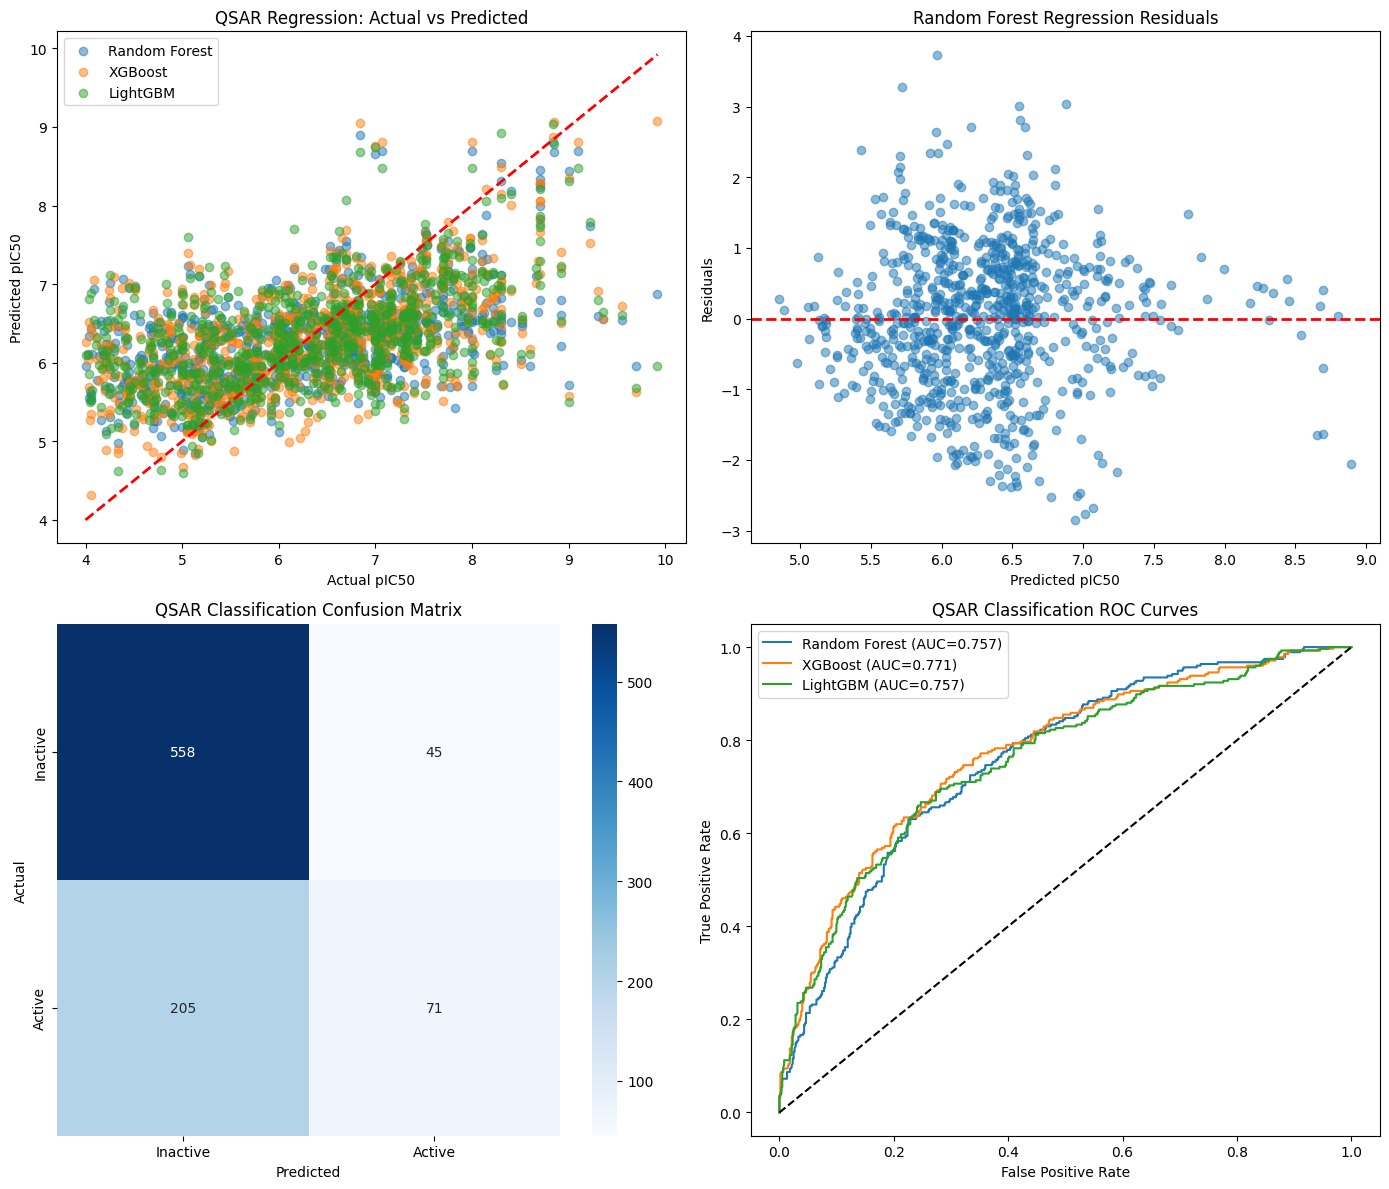


✅ Visualization saved as 'model_performance.png'


In [14]:
# ============================================
# PART 10: VISUALIZATIONS
# ============================================

print("\n" + "="*60)
print("📊 STEP 10: Visualizations")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# QSAR Regression: Actual vs Predicted
ax = axes[0, 0]
ax.scatter(y_qsar_test, y_pred_rf_reg, alpha=0.5, label='Random Forest')
ax.scatter(y_qsar_test, y_pred_xgb_reg, alpha=0.5, label='XGBoost')
ax.scatter(y_qsar_test, y_pred_lgb_reg, alpha=0.5, label='LightGBM')
ax.plot([y_qsar_test.min(), y_qsar_test.max()], [y_qsar_test.min(), y_qsar_test.max()], 'r--', linewidth=2)
ax.set_xlabel('Actual pIC50')
ax.set_ylabel('Predicted pIC50')
ax.set_title('QSAR Regression: Actual vs Predicted')
ax.legend()

# QSAR Regression: Residuals
ax = axes[0, 1]
residuals = y_qsar_test - y_pred_rf_reg
ax.scatter(y_pred_rf_reg, residuals, alpha=0.5)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted pIC50')
ax.set_ylabel('Residuals')
ax.set_title('Random Forest Regression Residuals')

# QSAR Classification: Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(y_qsar_test_cls, y_pred_rf_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('QSAR Classification Confusion Matrix')
ax.set_xticklabels(['Inactive', 'Active'])
ax.set_yticklabels(['Inactive', 'Active'])

# QSAR Classification: ROC Curve
ax = axes[1, 1]
from sklearn.metrics import roc_curve
for name, y_proba in [('Random Forest', y_proba_rf_cls),
                       ('XGBoost', y_proba_xgb_cls),
                       ('LightGBM', y_proba_lgb_cls)]:
    fpr, tpr, _ = roc_curve(y_qsar_test_cls, y_proba)
    auc_score = roc_auc_score(y_qsar_test_cls, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('QSAR Classification ROC Curves')
ax.legend()

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as 'model_performance.png'")


In [15]:
# ============================================
# PART 11: DOWNLOAD FILES FOR DEPLOYMENT
# ============================================

print("\n" + "="*60)
print("📥 STEP 11: Download Files for Deployment")
print("="*60)

# Files needed for deployment
deployment_files = [
    # QSAR Models
    'qsar_best_regressor.pkl',
    'qsar_best_classifier.pkl',

    # Scaler
    'scaler_qsar.joblib',

    # Feature Names
    'qsar_feature_names.txt',

    # Results (optional)
    'qsar_regression_results.csv',
    'qsar_classification_results.csv',
    'model_performance.png'
]

print("\n📌 Downloading Deployment Files:")
for file in deployment_files:
    try:
        files.download(file)
        print(f"   ✅ {file}")
    except:
        print(f"   ❌ {file} - NOT FOUND")

print("\n" + "="*60)
print("✅ ALL FILES DOWNLOADED!")
print("="*60)

print("\n📁 Files Summary:")
print("="*60)
print(f"📦 Total files: {len(deployment_files)}")
print("\n📂 Create a folder called 'models' and place these files:")
print("   - qsar_best_regressor.pkl")
print("   - qsar_best_classifier.pkl")
print("   - scaler_qsar.joblib")
print("   - qsar_feature_names.txt")

print("\n" + "="*60)
print("✅ QSAR MODEL BUILDING COMPLETE!")
print("="*60)



📥 STEP 11: Download Files for Deployment

📌 Downloading Deployment Files:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ qsar_best_regressor.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✅ qsar_classification_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✅ model_performance.png

✅ ALL FILES DOWNLOADED!

📁 Files Summary:
📦 Total files: 7

📂 Create a folder called 'models' and place these files:
   - qsar_best_regressor.pkl
   - qsar_best_classifier.pkl
   - scaler_qsar.joblib
   - qsar_feature_names.txt

✅ QSAR MODEL BUILDING COMPLETE!
